In [1]:
import pandas as pd

file_path = "../Telco_customer_churn.xlsx"

# Try reading as CSV first since the snippet looked like CSV
try:
    df = pd.read_csv(file_path)
    print("Successfully read as CSV")
    print(df.head())
    print(df.columns)
except Exception as e:
    print(f"Failed to read as CSV: {e}")
    # If CSV fails, try Excel (though the snippet suggests CSV)
    try:
        df = pd.read_excel(file_path)
        print("Successfully read as Excel")
        print(df.head())
    except Exception as e_excel:
        print(f"Failed to read as Excel: {e_excel}")

Failed to read as CSV: 'utf-8' codec can't decode byte 0x82 in position 16: invalid start byte
Successfully read as Excel
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  3

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Check data types and look for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

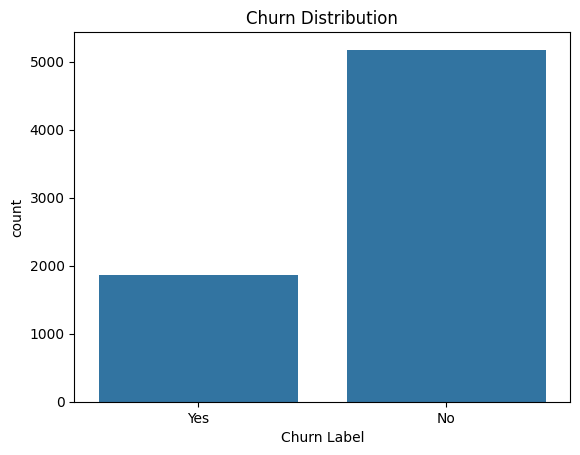

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [4]:
# Visualize the churn split
sns.countplot(x='Churn Label', data=df)
plt.title('Churn Distribution')
plt.show()

# Get the exact percentages
print(df['Churn Label'].value_counts(normalize=True) * 100)

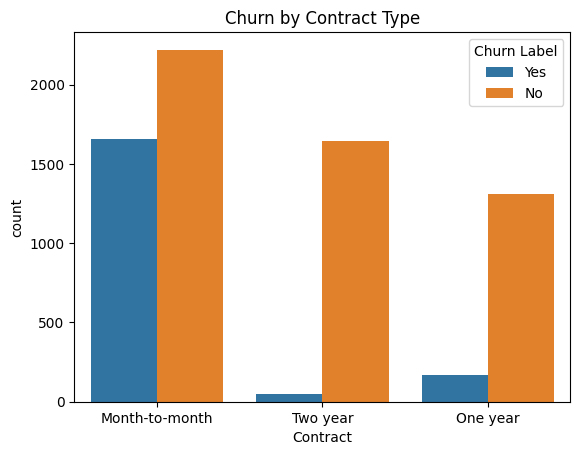

In [6]:
# See how contract type affects churn
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.title('Churn by Contract Type')
plt.show()

In [7]:
# 1. Force 'Total Charges' to be a number. 'coerce' turns blank spaces into NaN (Not a Number)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# 2. Let's see how many NaNs we just created
print("Missing values before dropping:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 3. Drop those specific rows (it's usually only about 11 rows out of 7000, so we won't miss them)
df.dropna(subset=['Total Charges'], inplace=True)

print("\nShape of dataset after cleaning:", df.shape)

Missing values before dropping:
Total Charges      11
Churn Reason     5174
dtype: int64

Shape of dataset after cleaning: (7032, 33)


In [8]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
print(numerical_cols)


Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score',
       'CLTV'],
      dtype='object')


In [9]:
df[numerical_cols].describe()


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7032.0,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,1.0,93523.032565,36.283307,-119.799215,32.421786,64.798208,2283.300441,0.265785,58.715301,4401.445108
std,0.0,1865.515958,2.456118,2.157588,24.545260,30.085974,2266.771362,0.441782,21.531321,1182.414266
min,1.0,90001.000000,32.555828,-124.301372,1.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.587500,401.450000,0.000000,40.000000,3469.750000
50%,1.0,93552.500000,36.391777,-119.735410,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.500000
75%,1.0,95354.000000,38.227285,-118.043237,55.000000,89.862500,3794.737500,1.000000,75.000000,5381.000000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


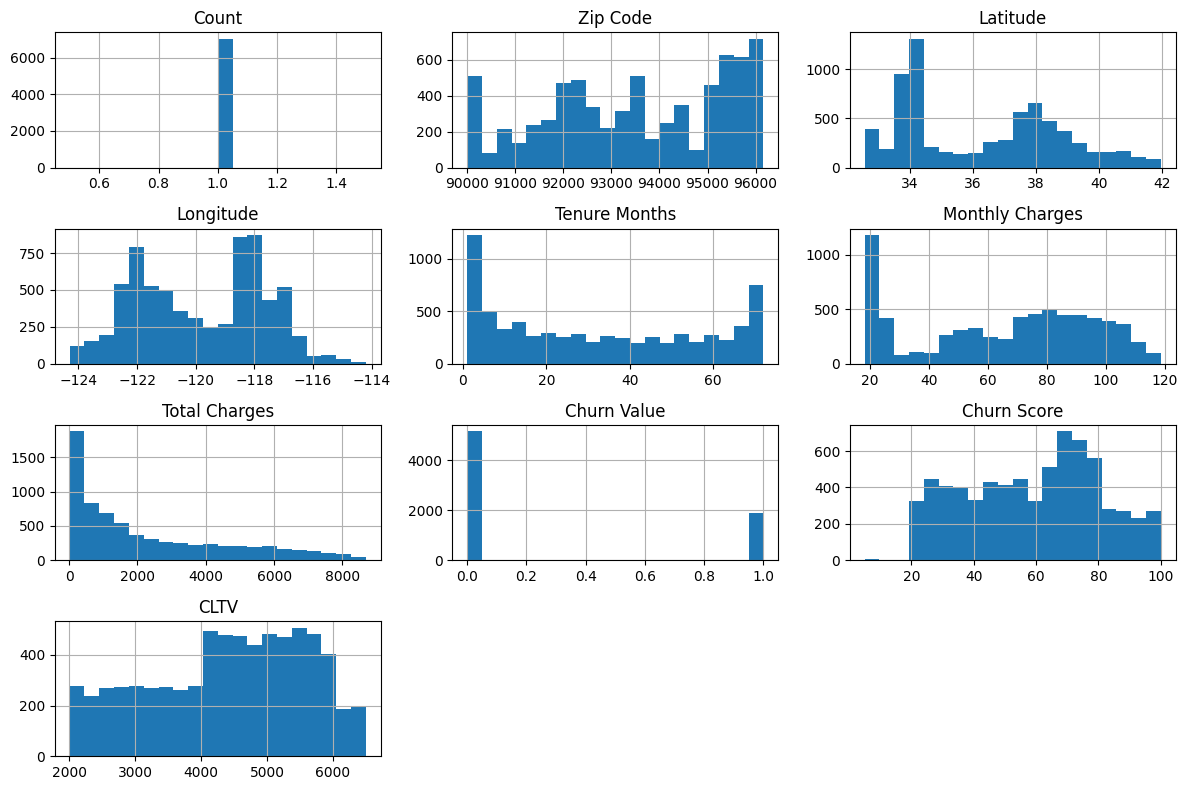

In [10]:
df[numerical_cols].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()


In [11]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)


Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Churn Label', 'Churn Reason'],
      dtype='object')


In [13]:
for col in categorical_cols:
    if col != 'customerID':
        print(f"\n{col}")
        print(df[col].value_counts())



CustomerID
CustomerID
3668-QPYBK    1
9237-HQITU    1
9305-CDSKC    1
7892-POOKP    1
0280-XJGEX    1
             ..
2569-WGERO    1
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
3186-AJIEK    1
Name: count, Length: 7032, dtype: int64

Country
Country
United States    7032
Name: count, dtype: int64

State
State
California    7032
Name: count, dtype: int64

City
City
Los Angeles      304
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
                ... 
Manton             4
Ben Lomond         3
Cupertino          3
Independence       3
Redcrest           3
Name: count, Length: 1129, dtype: int64

Lat Long
Lat Long
34.159534, -116.425984    5
33.28156, -115.955541     5
34.201108, -116.593456    5
33.798266, -118.300237    5
33.391181, -118.421305    5
                         ..
37.306612, -122.080621    3
37.590421, -122.306467    3
36.869584, -118.189241    3
34.084909, -117.258107    3
40.363446, -123.835041    3
Name: count, Length: 1652, dt

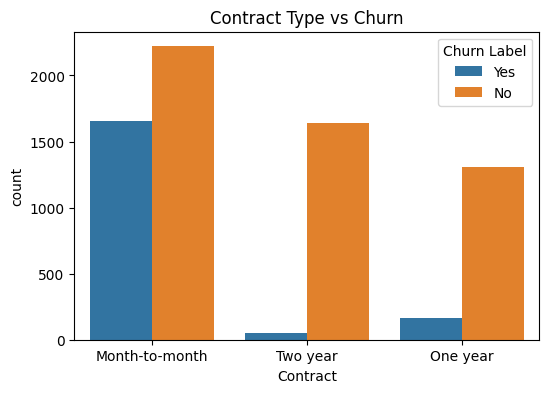

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.title("Contract Type vs Churn")
plt.show()

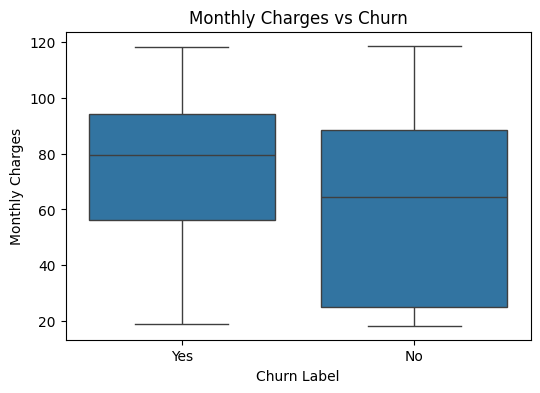

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

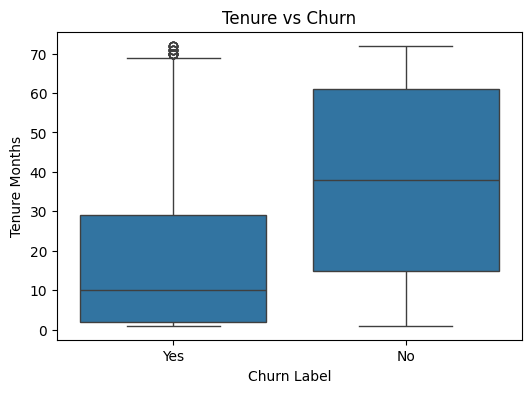

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn Label', y='Tenure Months', data=df)
plt.title("Tenure vs Churn")
plt.show()

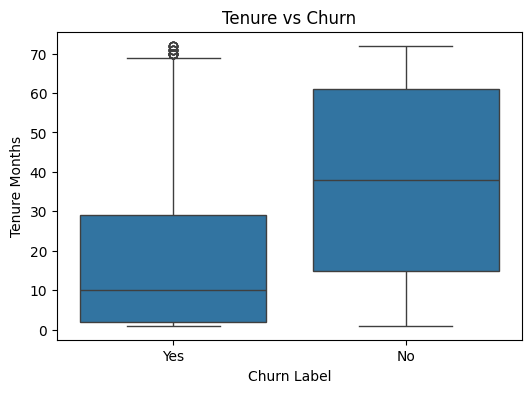

In [ ]:
# Example feature engineering idea
df['AvgMonthlySpend'] = df['Total Charges'] / (df['Tenure Months'] + 1)

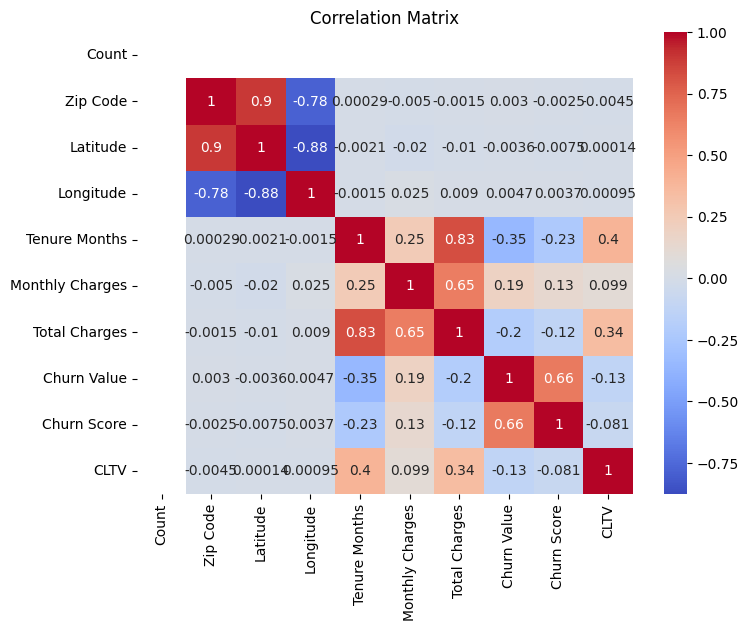

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


Customers with month-to-month contracts have higher churn.

Higher monthly charges correlate with higher churn probability.

Customers with shorter tenure churn more.

Dataset shows moderate class imbalance (~26% churn).

In [26]:
# Example feature engineering idea
df['AvgMonthlySpend'] = df['Total Charges'] / (df['Tenure Months'] + 1)

Created derived feature representing average monthly spending.

In [28]:
# Top churn reasons
churned = df[df['Churn Label'] == 'Yes']
print("Top 3 churn reasons:")
print(churned['Churn Reason'].value_counts().head(3))

Top 3 churn reasons:
Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Name: count, dtype: int64
